# Temporal Convolution Netword (TCN) driven Exploratory Data Analysis (EDA)

The purpose of this EDA is to describe the statistical properties of the time series, but also to choose the best data transformations, preprocessing strategies, and architectural choices for the downstream TCN.

---
## Dataset Import and Description

The five benchmark datasets being explored consist of a univariate time series indexed by time.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# loading helper
def load_and_preprocess(file, date_col=None):
    df = pd.read_csv(file)
    if date_col and date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
    return df

# load datasets
data_folder = "../data/"
df_electricity = load_and_preprocess(data_folder+'electricity.csv', 'date')
df_solar = load_and_preprocess(data_folder+'solar.csv', 'date')
df_traffic = load_and_preprocess(data_folder+'traffic.csv') # No date column in dataset, uses hours_from_start
df_volatility = load_and_preprocess(data_folder+'volatility.csv', 'date')
df_wind = load_and_preprocess(data_folder+'wind.csv', 'date')


# Configuration based on dataset format
configs = {
  "electricity": {"df": df_electricity, "id_target": "MT_001", "id_col": "id", "target_col": "power_usage", "date_col": "date"},
  "solar": {"df": df_solar, "id_target": 0, "id_col": "id", "target_col": "power_mw", "date_col": "date"},
  "traffic": {"df": df_traffic, "id_target": 400000, "id_col": "id", "target_col": "occupancy", "date_col": "hours_from_start"},
  "volatility": {"df": df_volatility, "id_target": ".AEX", "id_col": "Symbol", "target_col": "log_vol", "date_col": "date"},
  "wind": {"df": df_wind, "id_target": "AT", "id_col": "id", "target_col": "power_output", "date_col": "date"}
}

series_dict = {}

for name, cfg in configs.items():
    subset = cfg['df'][cfg['df'][cfg['id_col']] == cfg['id_target']].copy()
    subset = subset.sort_values(cfg['date_col'])
    subset = subset.set_index(cfg['date_col'])
    series_dict[name] = subset[cfg['target_col']]

First of all, we can count how many time series each dataset stores:

In [3]:
# Mapping of dataset name to its specific ID column
id_columns = {
    "electricity": "id",
    "solar": "id",
    "traffic": "id",
    "volatility": "Symbol",
    "wind": "id"
}

# Dictionary to store counts
series_counts = {
    "electricity": df_electricity[id_columns["electricity"]].nunique(),
    "solar": df_solar[id_columns["solar"]].nunique(),
    "traffic": df_traffic[id_columns["traffic"]].nunique(),
    "volatility": df_volatility[id_columns["volatility"]].nunique(),
    "wind": df_wind[id_columns["wind"]].nunique()
}

df_counts = pd.DataFrame.from_dict(series_counts, orient='index', columns=['unique_series_count'])
print(df_counts)

             unique_series_count
electricity                  369
solar                        137
traffic                      963
volatility                    31
wind                          28


We can also examine the characteristics of the time series from each dataset. In the following, a single time series form each dataset is taken as representative:

In [4]:
# summary helper
def summarize_ts(ts):
    return {
    'start': ts.index.min(),
    'end': ts.index.max(),
    'n_obs': ts.shape[0],
    'missing_%': ts.isna().mean() * 100,
    'mean': ts.mean(),
    'std': ts.std(),
    'min': ts.min(),
    'max': ts.max()
    }

summary_list = []
for name, ts in series_dict.items():
    stats = summarize_ts(ts)
    stats['dataset'] = name
    summary_list.append(stats)

df_eda_summary = pd.DataFrame(summary_list).set_index('dataset')
print(df_eda_summary[['n_obs', 'mean', 'std', 'min', 'max', 'missing_%']])

             n_obs       mean        std        min        max  missing_%
dataset                                                                  
electricity   6000   4.656885   5.842070   0.000000  34.581218        0.0
solar        52560  13.573475  17.611179   0.000000  58.850000        0.0
traffic       4151   0.049574   0.026267   0.005383   0.352417        0.0
volatility    5459  -9.682930   1.018837 -13.355362  -5.472597        0.0
wind         10957   0.126157   0.060725   0.000000   0.255319        0.0


We can thus see that each dataset contains a large number of time series, each holding numerous observatons. As expected, there are no missing values.

---
## Temporal Dependencies and Receptive Field Requirements

Autocorrelation analysis can be used to estimate the minimum receptive field that the TCN must cover.

Significant autocorrelation at large lags implies that:
- the dilation schedule must expand accordingly;
- shallow networks may fail to capture long-range dependencies.

The largest lag with significant correlation provides a lower bound on the required temporal context.

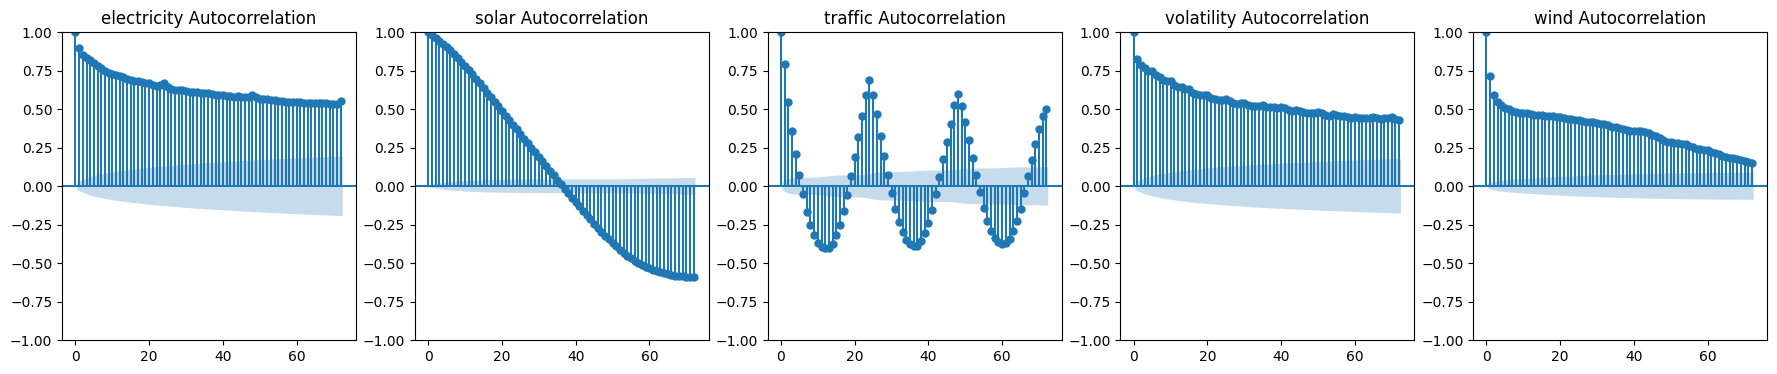

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (name, ts) in enumerate(series_dict.items()):
    plot_acf(ts.dropna(), lags=72, ax=axes[i], title=f"{name} Autocorrelation")

**Traffic**: As the most structured ACF, it shows clear peaks at lags 24, 48, and 72. The receptive field of the TCN must be at least 24 to see the daily pattern, but 168 (weekly) would probably be better.

**Electricity**: High initial persistence that slowly levels off. It lacks the sharp rhythmic peaks of Traffic, suggesting dependencies are more about recent history than strict hour-of-day cycles, as one could expect from this type of data.

**Solar**: Shows a parabolic wave ACF. It hits a local peak at 24 and 48, but the correlation is much broader than Traffic.

**Volatility**: Very slow, linear decay. Correlation is still >0.5 at lag 72, confirming Long Memory. TCN will need a high dilation base and many layers to capture this long-term dependency.

**Wind**: A rapid initial drop followed by a very slow, noisy decay. This suggests a mix of high-frequency noise and low-frequency trends.

---
## Global and Local Temporal Structure

We plot a visualization of the raw time series to identify large-scale patterns such as:
- long-term trends;
- visible seasonal cycles;
- extreme events.

This step provides a high-level understanding of the signal, but is not sufficient as TCN depend primarily on local temporal behavior within fixed windows: local stationarity within windows is more relevant than global stationarity.

The Rolling Mean is also plotted over the time series, tuning the window size based on results from autocorrelation plots to quantitatively find a starting point for the later stages of the method developement.

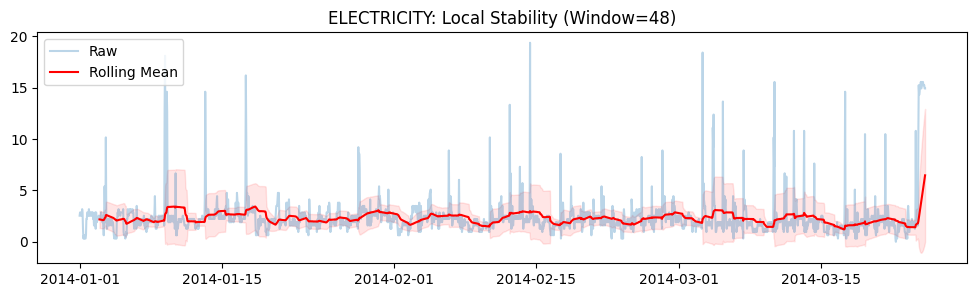

In [6]:
def plot_stability(ts, name, window=128):
    plt.figure(figsize=(12, 3))
    ts_roll_mean = ts.rolling(window).mean()
    ts_roll_std = ts.rolling(window).std()
    
    plt.plot(ts, alpha=0.3, label='Raw')
    plt.plot(ts_roll_mean, label='Rolling Mean', color='red')
    plt.fill_between(ts.index, ts_roll_mean - ts_roll_std, ts_roll_mean + ts_roll_std, color='red', alpha=0.1)
    plt.title(f"{name.upper()}: Local Stability (Window={window})")
    plt.legend()
    plt.show()

plot_stability(series_dict["electricity"].head(2000), "electricity", window=48)

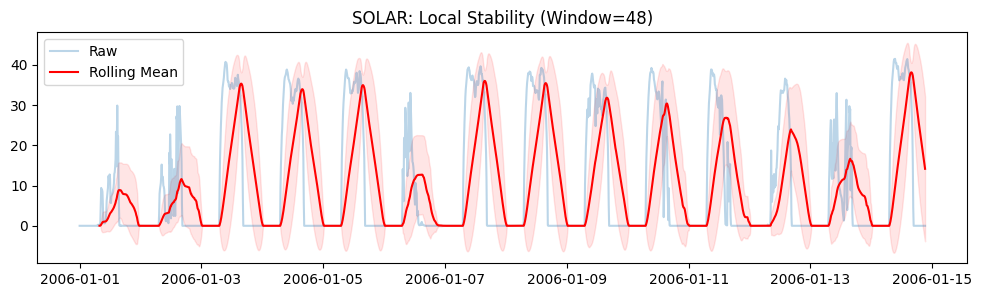

In [20]:

plot_stability(series_dict["solar"].head(2000), "solar", window=48)

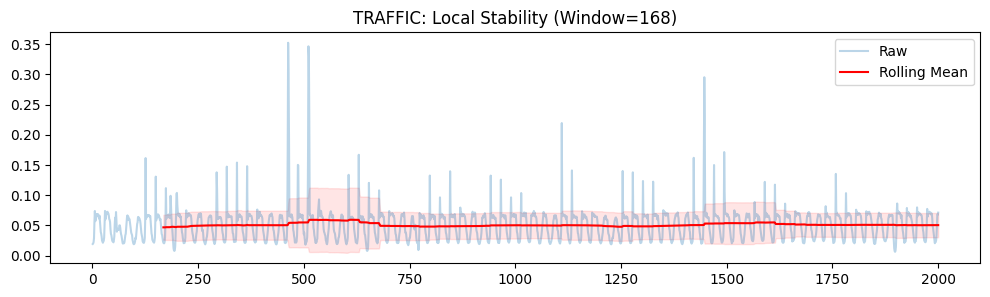

In [18]:

plot_stability(series_dict["traffic"].head(2000), "traffic", window=168) # confirms hypothesis from ACF plot, multiples of 24 are good window sizes

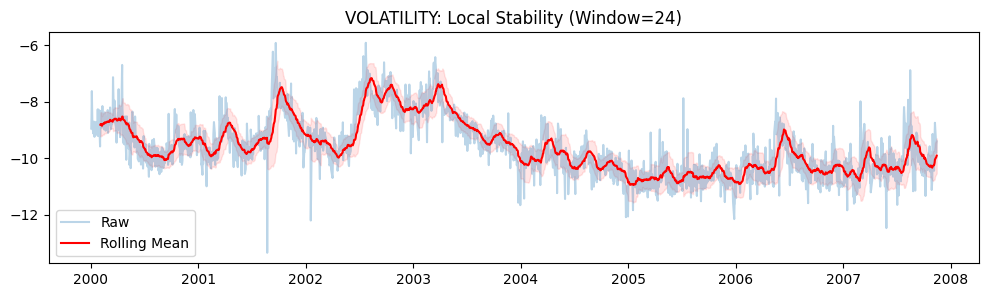

In [9]:

plot_stability(series_dict["volatility"].head(2000), "volatility", window=24)

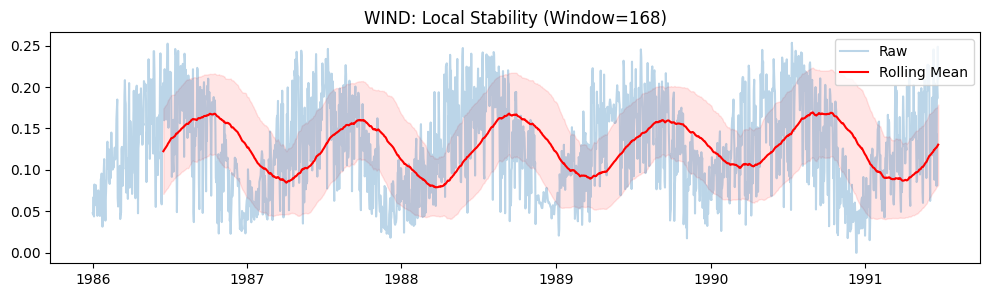

In [10]:

plot_stability(series_dict["wind"].head(2000), "wind", window=168)

**Electricity**: The rolling mean is stable, but the signals shows extreme, sparse spikes. using RobustScaler to ignore these spikes during normalization could improve performance.

**Solar**: The rolling mean follows a clear periodic wave. There is no long-term drift, but the variance is high during the day and zero at night.

**Traffic**: Stable pattern, with only a few outliers. The periodic pattern is consistent over the examined snippet.

**Volatility**: This is the only series showing significant regime changes. The mean shifts drastically between 2002 (high) and 2005 (low). A global scaler may fail here, we probably should Differenciate the series before using them.

**Wind**: Shows a slow, seasonal-style oscillation in the mean. The local variance (pink shaded area) remains relatively constant throughout.

---
In the following, we adress the long-term shifts in the Volatility dataset applying First-Order Differenciation to stabilize the mean and compare the results:

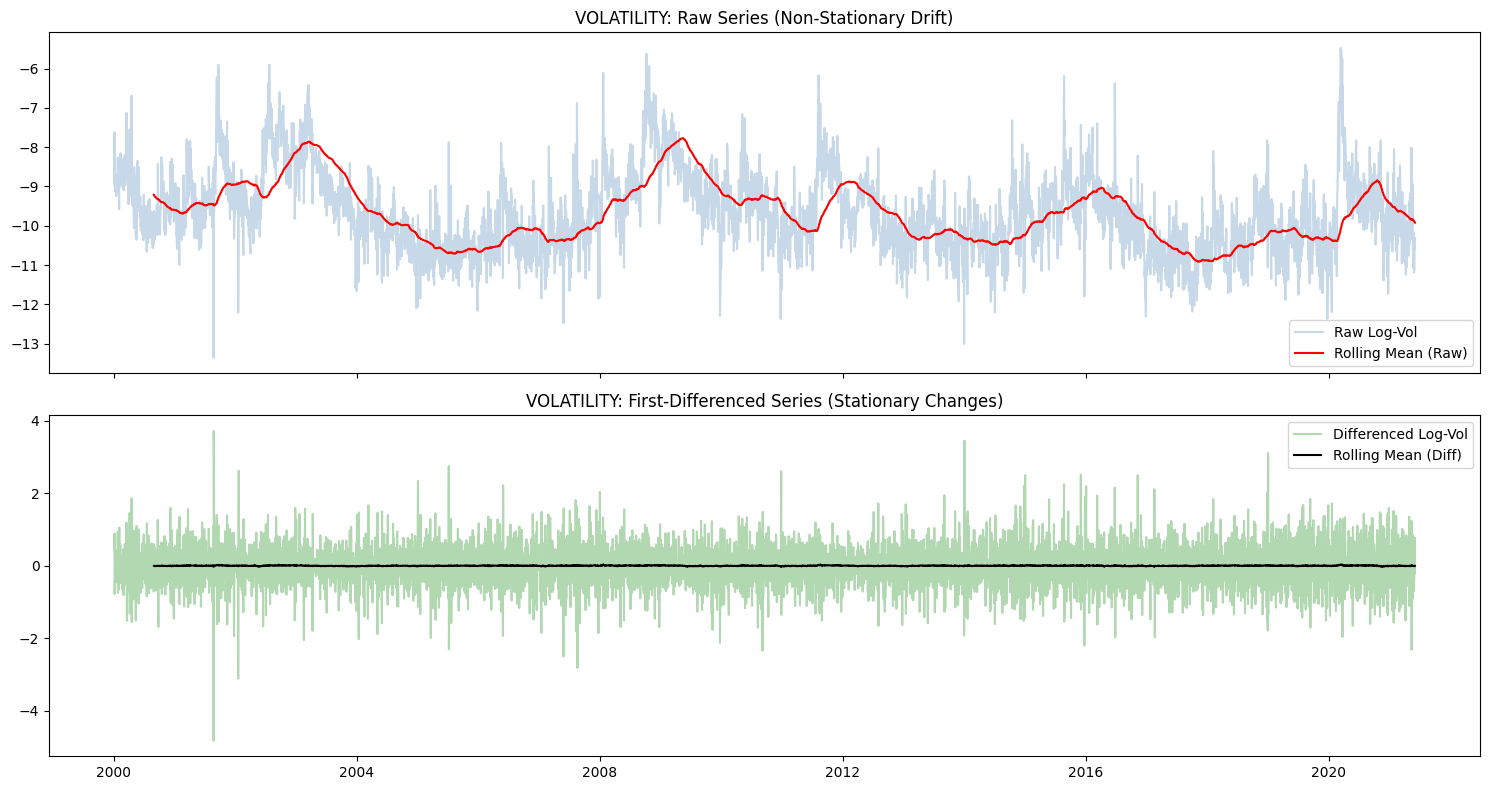

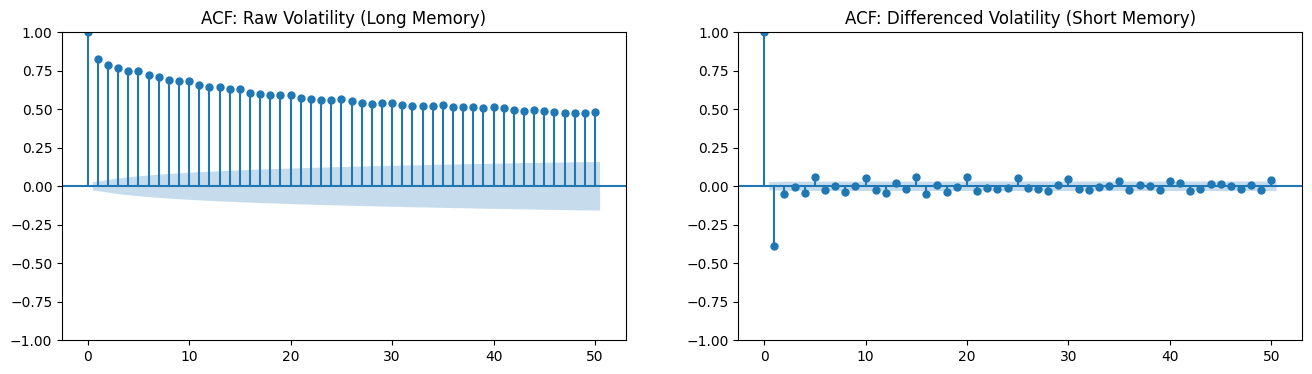

In [11]:
vol_raw = series_dict['volatility']
vol_diff = vol_raw.diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(vol_raw, alpha=0.3, color='steelblue', label='Raw Log-Vol')
ax1.plot(vol_raw.rolling(168).mean(), color='red', label='Rolling Mean (Raw)')
ax1.set_title("VOLATILITY: Raw Series (Non-Stationary Drift)")
ax1.legend()

ax2.plot(vol_diff, alpha=0.3, color='green', label='Differenced Log-Vol')
ax2.plot(vol_diff.rolling(168).mean(), color='black', label='Rolling Mean (Diff)')
ax2.set_title("VOLATILITY: First-Differenced Series (Stationary Changes)")
ax2.legend()

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(vol_raw.dropna(), lags=50, ax=ax1, title="ACF: Raw Volatility (Long Memory)")
plot_acf(vol_diff.dropna(), lags=50, ax=ax2, title="ACF: Differenced Volatility (Short Memory)")
plt.show()

The results for the differenciated time series are much better, so we can consider using this transformation on the dataset before passing it to the models for training. 

---
## Seasonal Operationalization

In our TCNs, we must decide wether we want to encode time as a feature or let the TCN learn it via deep filters.

Dataset     | Seasonality             | Encoding         | Motivation
------------|-------------------------|------------------|--------------------------------
Electricity |	Diurnal & Weekly      |Encode (Sin/Cos)  | Electricity usage is tied to human routines along the week.
Solar	    | Diurnal (Daily)	      | Encode (Sin/Cos) | Hard zero-values at night are easier for the model if it has an explicit clock input.
Traffic	    | Daily & Weekly	      | Fourier Features | High complexity seasonality is better served by external encodings than deep networks alone.
Wind	    | Weak, Stochastic    	  | None             | The TCN will act as a noise-reducing filter.   
Volatility	| None (Structural Trend) |	Differencing     | Seasonal encoding of finantial volatility is often noise; Differencing we remove the trend and stabilize the mean.

---
## Value Distribution and Scaling Implications

Convolutional neural networks are sensitive to the scale and distribution of inputs. This section examines:
- skewness and heavy tails;
- presence of extreme values;
- bounded or strictly positive domains.

The goal is to determine whether transformations such as logarithmic scaling, robust normalization, or per-window standardization are required to ensure stable gradient flow during training.

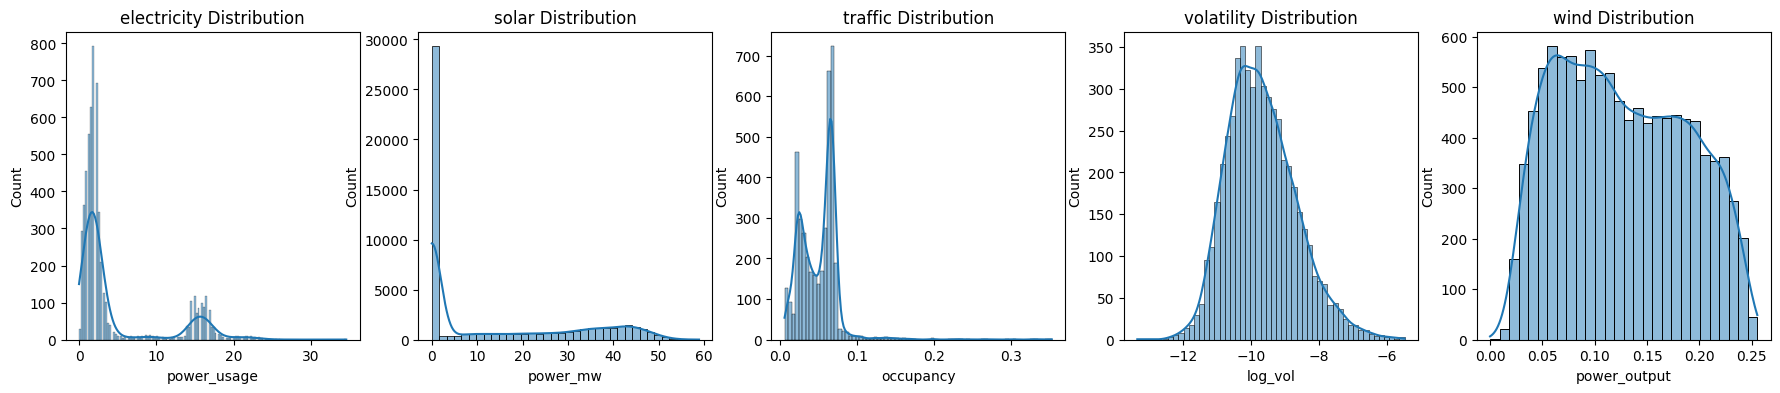

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (name, ts) in enumerate(series_dict.items()):
    sns.histplot(ts, kde=True, ax=axes[i])
    axes[i].set_title(f"{name} Distribution")

**Electricity (Heavy-Tailed)**: The distribution is bimodal with a long tail to the right. Standard MSE loss will be skewed by the outliers, so alternatives like Huber Loss can be utilized for more robust training.

**Solar (Zero-Inflated)**: As expected, we can see a spike at the value 0.0. The use of a ReLU or similiar functions on the final layer ensures the model never predicts negative sunlight.

**Traffic (Bimodal)**: We can distinguish clear peaks representing free flow of cars and congested states. The TCN needs enough hidden channels to distinguish between these two regimes.

**Volatility (Gaussian)**: The log_vol is almost perfectly normally distributed. This is ideal for neural networks. Standard MSE loss and StandardScaler should work perfectly.

**Wind (Skewed/Bounded)**: Most values cluster between 0.05 and 0.15, capped at ~0.25. the use of StandardScaler can be appropriate.

---
We can also plot the distribution of the differenced Volatility, as we discussed that it forms a better dataset compared to the original, semi-random values:

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
C:\Users\test1\AppData\Local\Temp\ipykernel_11820\1903163710.py:12: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_xlabel("Change in log_vol ($\Delta$)")


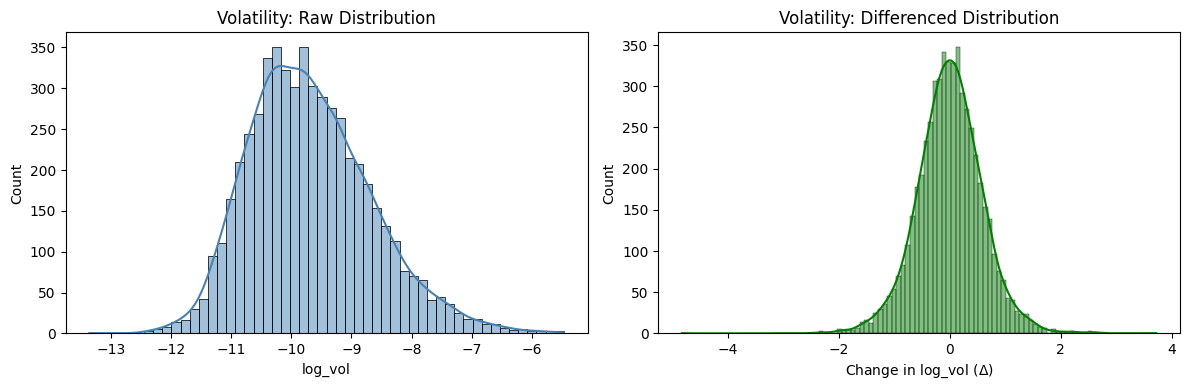

Raw Volatility Mean: -9.6829
Differenced Volatility Mean: -0.0002


In [13]:
vol_raw = series_dict['volatility']
vol_diff = vol_raw.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(vol_raw, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Volatility: Raw Distribution")
axes[0].set_xlabel("log_vol")

sns.histplot(vol_diff, kde=True, ax=axes[1], color='green')
axes[1].set_title("Volatility: Differenced Distribution")
axes[1].set_xlabel("Change in log_vol ($\Delta$)")

plt.tight_layout()
plt.show()

print(f"Raw Volatility Mean: {vol_raw.mean():.4f}")
print(f"Differenced Volatility Mean: {vol_diff.mean():.4f}")

We can notice that the differenced distribution is perfectly centered at 0.0. This will ensure that the TCNs' weights will not be biased by the absolute magnitude of the input.\
The differenced distribution is also tighter wrt the original data and resembles a Gaussian distribution, indicating that the noise is now the primary signal.

The range of the differenced data is significantly smaller, allowing for much more stable gradient descent during training, as the activations in the causal convolution layers are less likely to saturate.